In [1]:
from google.colab import files
uploaded = files.upload("customer_sales_data.csv")

Saving customer_sales_data.csv to customer_sales_data.csv/customer_sales_data.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("customer_sales_data.csv", parse_dates=["Order_Date"])

# -----------------------------
# 1. BASIC DATA INSPECTION
# -----------------------------

print("DATASET SHAPE")
print(df.shape)

print("\nFIRST 5 ROWS")
display(df.head())

print("\nDATA TYPES")
print(df.dtypes)

# -----------------------------
# 2. DATA QUALITY CHECK
# -----------------------------

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

# -----------------------------
# 3. BUSINESS KPIs
# -----------------------------

total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_quantity = df["Quantity"].sum()
profit_margin = total_profit / total_revenue
average_order_value = total_revenue / total_orders

print("\n" + "="*40)
print("BUSINESS KPIs")
print("="*40)

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Profit: £{total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2%}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Units Sold: {total_quantity:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

# -----------------------------
# 4. CATEGORY ANALYSIS
# -----------------------------

category_analysis = (
    df.groupby("Category")
      .agg(
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order_ID", "nunique"),
          Units=("Quantity", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

print("\nREVENUE & PROFIT BY CATEGORY")
display(category_analysis)

# -----------------------------
# 5. REGIONAL ANALYSIS
# -----------------------------

region_analysis = (
    df.groupby("Region")
      .agg(
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order_ID", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

print("\nREVENUE & PROFIT BY REGION")
display(region_analysis)

# -----------------------------
# 6. CUSTOMER SEGMENT ANALYSIS
# -----------------------------

segment_analysis = (
    df.groupby("Customer_Segment")
      .agg(
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order_ID", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

print("\nREVENUE & PROFIT BY CUSTOMER SEGMENT")
display(segment_analysis)

# -----------------------------
# 7. MONTHLY ANALYSIS
# -----------------------------

df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

monthly_analysis = (
    df.groupby("Month")
      .agg(
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

print("\nMONTHLY PERFORMANCE")
display(monthly_analysis)

# -----------------------------
# 8. TOP PRODUCTS
# -----------------------------

product_analysis = (
    df.groupby("Product")
      .agg(
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum"),
          Units=("Quantity", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

print("\nTOP 10 PRODUCTS BY REVENUE")
display(product_analysis.head(10))

DATASET SHAPE
(1000, 13)

FIRST 5 ROWS


,Order_ID,Order_Date,Customer_ID,Region,Customer_Segment,Category,Product,Quantity,Unit_Price,Discount,Revenue,Cost,Profit
0,498,2025-01-01,CUST-181,Leeds,Consumer,Fitness,Yoga Mat,2,32.79,0.0,65.59,37.67,27.92
1,164,2025-01-01,CUST-057,Sheffield,Consumer,Office,Notebook,1,70.58,0.0,70.58,44.42,26.16
2,70,2025-01-01,CUST-133,London,Consumer,Home,Coffee Maker,2,71.08,0.0,142.15,73.85,68.30
3,998,2025-01-02,CUST-195,Manchester,Consumer,Office,Office Chair,1,68.88,0.0,68.88,38.79,30.09
4,665,2025-01-02,CUST-127,Leeds,Corporate,Office,Notebook,3,71.48,0.0,214.44,151.91,62.53



DATA TYPES
Order_ID                     int64
Order_Date          datetime64[ns]
Customer_ID                 object
Region                      object
Customer_Segment            object
Category                    object
Product                     object
Quantity                     int64
Unit_Price                 float64
Discount                   float64
Revenue                    float64
Cost                       float64
Profit                     float64
dtype: object

MISSING VALUES
Order_ID            0
Order_Date          0
Customer_ID         0
Region              0
Customer_Segment    0
Category            0
Product             0
Quantity            0
Unit_Price          0
Discount            0
Revenue             0
Cost                0
Profit              0
dtype: int64

DUPLICATE ROWS
0

BUSINESS KPIs
Total Revenue: £208,760.83
Total Profit: £81,769.29
Profit Margin: 39.17%
Total Orders: 1,000
Total Units Sold: 2,933
Average Order Value: £208.76

REVENUE & PROFIT BY CAT

,Revenue,Profit,Orders,Units
Category,,,,
Electronics,79881.50,31426.00,229,696
Office,40097.05,15492.04,228,647
Home,37166.85,14691.85,183,512
Fitness,28223.84,11119.87,176,529
Accessories,23391.59,9039.53,184,549



REVENUE & PROFIT BY REGION


...

,Revenue,Profit,Orders
Customer_Segment,,,
Consumer,106934.80,42168.93,501
Corporate,63699.09,24727.28,306
Small Business,38126.94,14873.08,193



MONTHLY PERFORMANCE


,Month,Revenue,Profit
0,2025-01,17515.34,6973.96
1,2025-02,17242.89,7015.65
2,2025-03,16971.44,6519.14
3,2025-04,14735.66,5815.31
4,2025-05,17239.18,6832.42
5,2025-06,19973.76,7739.67
6,2025-07,17647.48,6887.50
7,2025-08,22667.59,8667.89
8,2025-09,17436.71,6979.09
9,2025-10,16074.86,6194.99



TOP 10 PRODUCTS BY REVENUE


,Revenue,Profit,Units
Product,,,
Monitor,22202.68,8632.25,184
Keyboard,19813.21,7843.44,175
Webcam,19777.21,7938.66,175
Wireless Headphones,18088.40,7011.65,162
Notebook,11418.10,4476.52,187
Storage Box,10781.76,4164.05,146
Desk Organiser,10244.32,3832.09,165
Air Purifier,9712.48,3936.40,135
Office Chair,9231.33,3647.79,145


In [3]:
import os

print(os.listdir())

['.config', 'customer_sales_data.csv', 'sample_data']


In [4]:
import shutil
from google.colab import files

# Remove the incorrect folder
shutil.rmtree("customer_sales_data.csv")

# Upload the actual CSV file
uploaded = files.upload()

Saving customer_sales_data.csv to customer_sales_data.csv


In [5]:
import os
print(os.path.isfile("customer_sales_data.csv"))

True


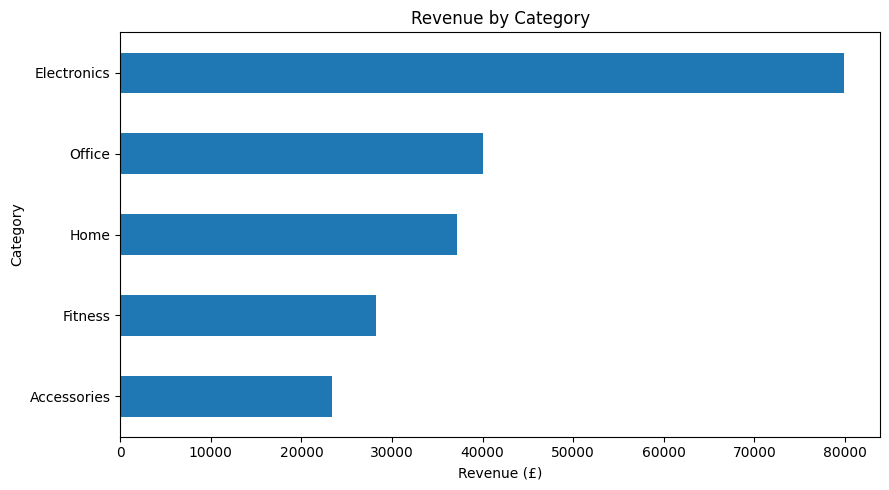

TypeError: FigureCanvasAgg.print_png() got an unexpected keyword argument 'bbox'

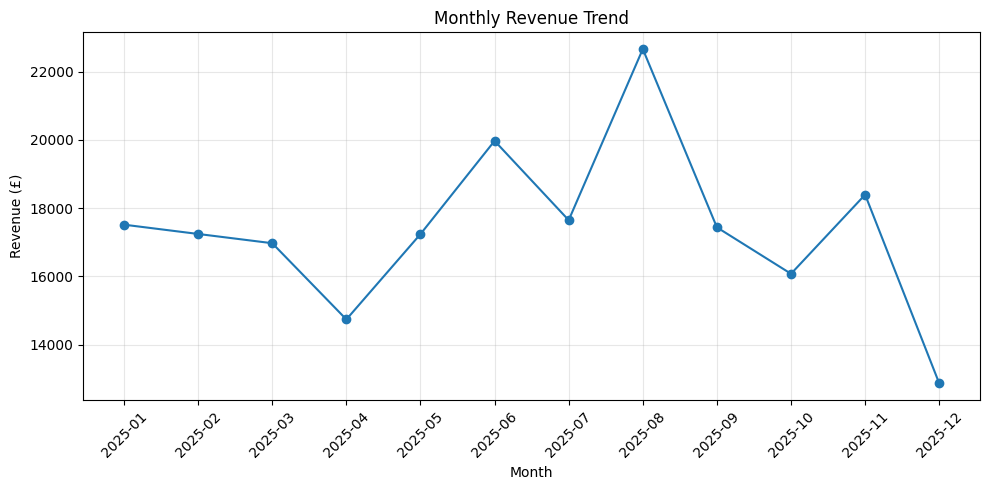

In [8]:
import matplotlib.pyplot as plt

# 1. Revenue by Category
plt.figure(figsize=(9, 5))
category_analysis["Revenue"].sort_values().plot(kind="barh")
plt.title("Revenue by Category")
plt.xlabel("Revenue (£)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("revenue_by_category.png", dpi=200, bbox_inches="tight")
plt.show()


# 2. Monthly Revenue Trend
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_analysis["Month"],
    monthly_analysis["Revenue"],
    marker="o"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("monthly_revenue.png", dpi=200, bbox="tight")
plt.show()


# 3. Profit by Region
plt.figure(figsize=(9, 5))
region_analysis["Profit"].sort_values().plot(kind="barh")
plt.title("Profit by Region")
plt.xlabel("Profit (£)")
plt.ylabel("Region")
plt.tight_layout()
plt.savefig("profit_by_region.png", dpi=200, bbox_inches="tight")
plt.show()

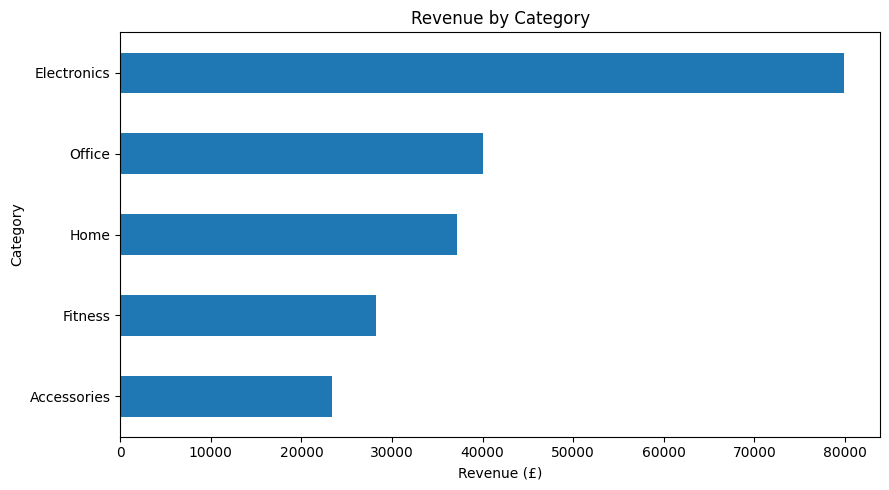

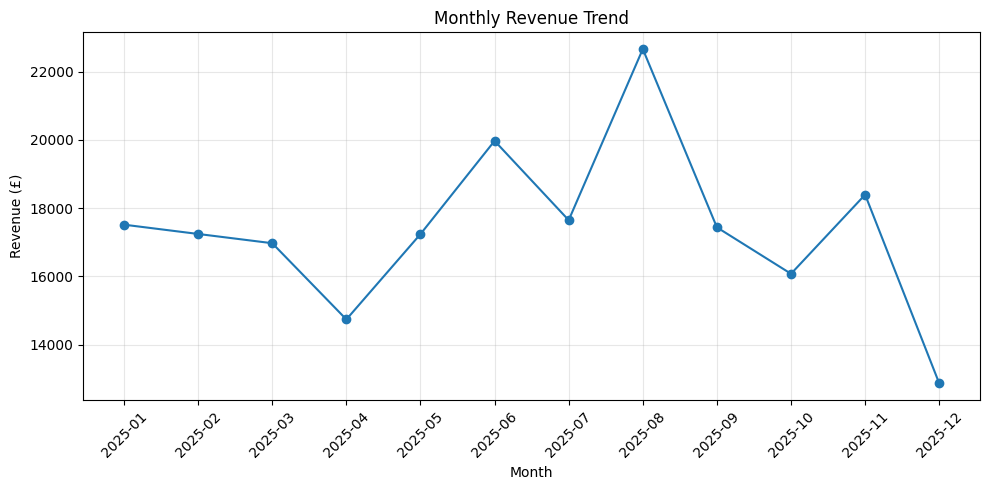

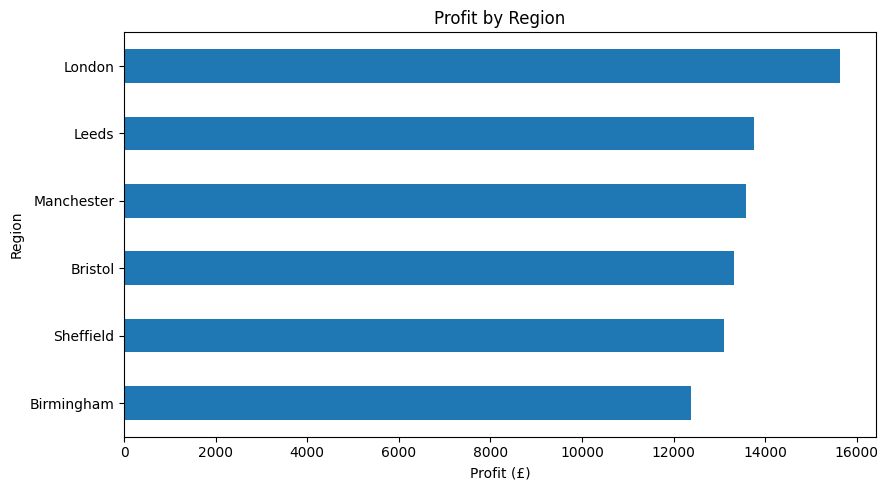

✅ All 3 charts created and saved successfully.


In [9]:
# Save the three charts correctly

# Revenue by Category
plt.figure(figsize=(9, 5))
category_analysis["Revenue"].sort_values().plot(kind="barh")
plt.title("Revenue by Category")
plt.xlabel("Revenue (£)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("revenue_by_category.png", dpi=200, bbox_inches="tight")
plt.show()


# Monthly Revenue
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_analysis["Month"],
    monthly_analysis["Revenue"],
    marker="o"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("monthly_revenue.png", dpi=200, bbox_inches="tight")
plt.show()


# Profit by Region
plt.figure(figsize=(9, 5))
region_analysis["Profit"].sort_values().plot(kind="barh")
plt.title("Profit by Region")
plt.xlabel("Profit (£)")
plt.ylabel("Region")
plt.tight_layout()
plt.savefig("profit_by_region.png", dpi=200, bbox_inches="tight")
plt.show()

print("✅ All 3 charts created and saved successfully.")

In [10]:
from google.colab import files

files.download("revenue_by_category.png")
files.download("monthly_revenue.png")
files.download("profit_by_region.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>